<a href="https://colab.research.google.com/github/elizabeth346/CUSTOMER-SEGMENTATION-ANALYSIS/blob/main/CUSTOMER_SEGMENTATION_ANALYSIS_PY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sk_silhouette_score

In [ ]:
#import our data
data=pd.read_csv("/content/customer_segmentation_data(1).csv")
data.head()

,Age,Annual_Income_Ksh,Spending_Score,Purchase_Frequency,Online_Engagement,Segment_Type
0,43.973713,93577.87360,64.055723,17.270966,84.382838,High Income - High Spender
1,38.893886,95607.84526,74.006250,12.233504,69.839553,High Income - High Spender
2,45.181508,100830.51240,80.052437,17.608818,75.961208,High Income - High Spender
3,52.184239,100538.02050,80.469806,19.066914,70.377247,High Income - High Spender
4,38.126773,76223.30632,75.499345,16.240305,70.655038,High Income - High Spender


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 600 non-null    float64
 1   Annual_Income_Ksh   600 non-null    float64
 2   Spending_Score      600 non-null    float64
 3   Purchase_Frequency  600 non-null    float64
 4   Online_Engagement   600 non-null    float64
 5   Segment_Type        600 non-null    object 
dtypes: float64(5), object(1)
memory usage: 28.3+ KB


In [ ]:
data["Segment_Type"].unique()

array(['High Income - High Spender', 'Low Income - Low Spender',
       'Young - High Online Engagement'], dtype=object)

In [ ]:
data1=data[["Age","Annual_Income_Ksh","Spending_Score","Purchase_Frequency","Online_Engagement"]]
data1.head(10)

,Age,Annual_Income_Ksh,Spending_Score,Purchase_Frequency,Online_Engagement
0,43.973713,93577.87360,64.055723,17.270966,84.382838
1,38.893886,95607.84526,74.006250,12.233504,69.839553
2,45.181508,100830.51240,80.052437,17.608818,75.961208
3,52.184239,100538.02050,80.469806,19.066914,70.377247
4,38.126773,76223.30632,75.499345,16.240305,70.655038
5,38.126904,80621.74960,86.228499,20.630387,71.908279
6,52.633703,95150.35267,69.323796,12.678632,77.221338
7,46.139478,95137.85951,78.576205,11.266036,70.212514
8,36.244205,95150.47686,81.202956,9.663839,87.557561
9,44.340480,128527.31490,85.144388,19.488133,66.053927


In [ ]:
#Because Kmean is a distance based algorithm ,we are going to scale our features
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data1)
scaled_data

array([[ 1.03990887,  1.38306613,  0.32266757,  1.54879367,  0.68015414],
       [ 0.52595738,  1.45970471,  0.76742549,  0.45866143,  0.0451742 ],
       [ 1.16210751,  1.65687879,  1.03767147,  1.62190654,  0.31245412],
       ...,
       [-0.8700699 , -0.56537545,  0.25471398, -0.79762126,  0.65432228],
       [-1.20426843, -0.19955147,  0.78506727, -0.18033152,  0.99836022],
       [-0.63295393, -0.2412081 , -0.12244911,  0.10564215,  0.89151307]])

In [ ]:
#Fitting our kmeans model
inertias=[]
silhouette_score_list=[]
k_values=range(2,20)
for k in k_values:
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(scaled_data)
  inertias.append(kmeans.inertia_)
  silhouette_score_list.append(sk_silhouette_score(scaled_data,kmeans.labels_))
  print(f"Silhouette score for k={k}: {sk_silhouette_score(scaled_data,kmeans.labels_)}")

Silhouette score for k=2: 0.48362681352680187
Silhouette score for k=3: 0.5104436723789814
Silhouette score for k=4: 0.4426803855260281
Silhouette score for k=5: 0.29189024902885163
Silhouette score for k=6: 0.24229392806472755
Silhouette score for k=7: 0.2164392475211382
Silhouette score for k=8: 0.2138165267021928
Silhouette score for k=9: 0.21214669462208188
Silhouette score for k=10: 0.20812517799858418
Silhouette score for k=11: 0.1940956889578765
Silhouette score for k=12: 0.19399185596969906
Silhouette score for k=13: 0.18690377729833846
Silhouette score for k=14: 0.1845937901369751
Silhouette score for k=15: 0.18127612090617948
Silhouette score for k=16: 0.17777989819150275
Silhouette score for k=17: 0.1745232570291542
Silhouette score for k=18: 0.17590388465132756
Silhouette score for k=19: 0.17399111802904735


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

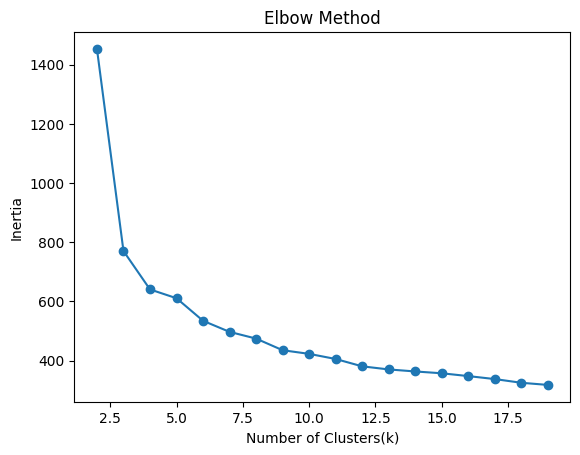

In [ ]:
plt.plot(k_values,inertias,marker="o")
plt.xlabel("Number of Clusters(k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt

In [ ]:
# From our plot we identified a region between 3 & 4 as our optimal value for k.

Text(0.5, 1.0, 'Silhouette Score vs Number of Clusters')

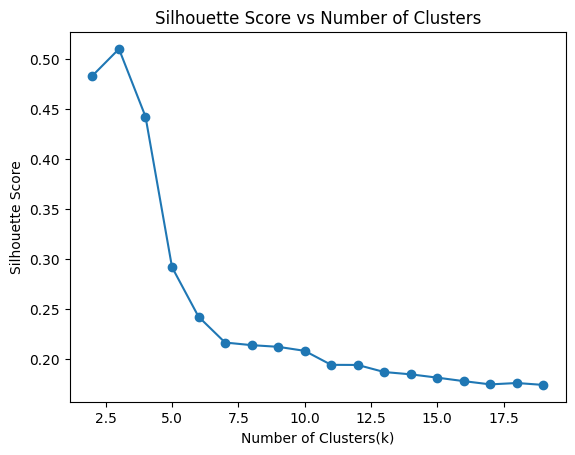

In [ ]:
plt.plot(k_values,silhouette_score_list,marker="o")
plt.xlabel("Number of Clusters(k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

In [ ]:
# Looking at the silhouette score the highest sections were between 3 & 4
# go ahead and to test and confirm the k value with a better davies bouldin score

In [ ]:
# Apply KMeans with the optimal number of clusters (k=3)
kmeans_optimal = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_optimal.fit(scaled_data)

# Add the cluster labels to the original dataframe
data1['Cluster'] = kmeans_optimal.labels_
display(data1.head())

/tmp/ipykernel_3011/2409072466.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Cluster'] = kmeans_optimal.labels_


,Age,Annual_Income_Ksh,Spending_Score,Purchase_Frequency,Online_Engagement,Cluster
0,43.973713,93577.87360,64.055723,17.270966,84.382838,2
1,38.893886,95607.84526,74.006250,12.233504,69.839553,2
2,45.181508,100830.51240,80.052437,17.608818,75.961208,2
3,52.184239,100538.02050,80.469806,19.066914,70.377247,2
4,38.126773,76223.30632,75.499345,16.240305,70.655038,2


In [ ]:
model1=KMeans(n_clusters=4,random_state=42)
model1.fit(scaled_data)
labels1=model1.labels_
data1["clusters1"]=labels1
data1.head(7)

,Age,Annual_Income_Ksh,Spending_Score,Purchase_Frequency,Online_Engagement,Cluster,clusters1
0,43.973713,93577.87360,64.055723,17.270966,84.382838,2,2
1,38.893886,95607.84526,74.006250,12.233504,69.839553,2,2
2,45.181508,100830.51240,80.052437,17.608818,75.961208,2,2
3,52.184239,100538.02050,80.469806,19.066914,70.377247,2,2
4,38.126773,76223.30632,75.499345,16.240305,70.655038,2,2
5,38.126904,80621.74960,86.228499,20.630387,71.908279,2,2
6,52.633703,95150.35267,69.323796,12.678632,77.221338,2,2


In [ ]:
#We will compare k=3 and k=4 with davies bouldin score and select the model that has a score which is closer to zero.
from sklearn.metrics import davies_bouldin_score

In [ ]:
davies_score_k3 = davies_bouldin_score(scaled_data, kmeans_optimal.labels_)
print(f"Davies Bouldin score for k=3: {davies_score_k3}")

Davies Bouldin score for k=3: 0.7235340418633887


In [ ]:
davies_score_k4 = davies_bouldin_score(scaled_data, labels1)
print(f"Davies Bouldin score for k=4: {davies_score_k4}")

Davies Bouldin score for k=4: 0.9504529020142976


In [ ]:
davies_score1=davies_bouldin_score(scaled_data,labels1)
print("Davies bouldin score of k=4=....",davies_score1)

Davies bouldin score of k=4=.... 0.9504529020142976


In [ ]:
# From the Davies bouldin score above ,k=3 has a score = 0.72 and k=4 has a score = 0.95.We agreed to choose a value of k which
#yields a score close to 0 and thus k=3 was the better option .

In [ ]:
profiles=data1.groupby("Cluster")[["Age","Annual_Income_Ksh","Spending_Score","Purchase_Frequency","Online_Engagement"]].mean()
profiles

,Age,Annual_Income_Ksh,Spending_Score,Purchase_Frequency,Online_Engagement
Cluster,,,,,
0,36.533106,30026.872467,30.661043,5.237594,40.224824
1,24.918115,50463.435661,61.077667,10.109585,89.740196
2,39.935303,91154.852219,79.132525,15.094661,76.178458


Now, let's look at the characteristics of each cluster to understand the different customer segments.

In [ ]:
# Analyze the characteristics of each cluster
cluster_summary = data.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual_Income_Ksh': 'mean',
    'Spending_Score': 'mean',
    'Purchase_Frequency': 'mean',
    'Online_Engagement': 'mean',
    'Segment_Type': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Cluster': 'count' # Count of customers in each cluster
})

cluster_summary.rename(columns={'Cluster': 'Number_of_Customers'}, inplace=True)
display(cluster_summary)

,Age,Annual_Income_Ksh,Spending_Score,Purchase_Frequency,Online_Engagement,Segment_Type,Number_of_Customers
Cluster,,,,,,,
0,36.533106,30026.872467,30.661043,5.237594,40.224824,Low Income - Low Spender,200
1,24.918115,50463.435661,61.077667,10.109585,89.740196,Young - High Online Engagement,204
2,39.935303,91154.852219,79.132525,15.094661,76.178458,High Income - High Spender,196


### Visualizing Customer Clusters

Let's visualize the clusters using a scatter plot to observe how different customer segments are distributed based on key features like 'Annual Income' and 'Spending Score'.

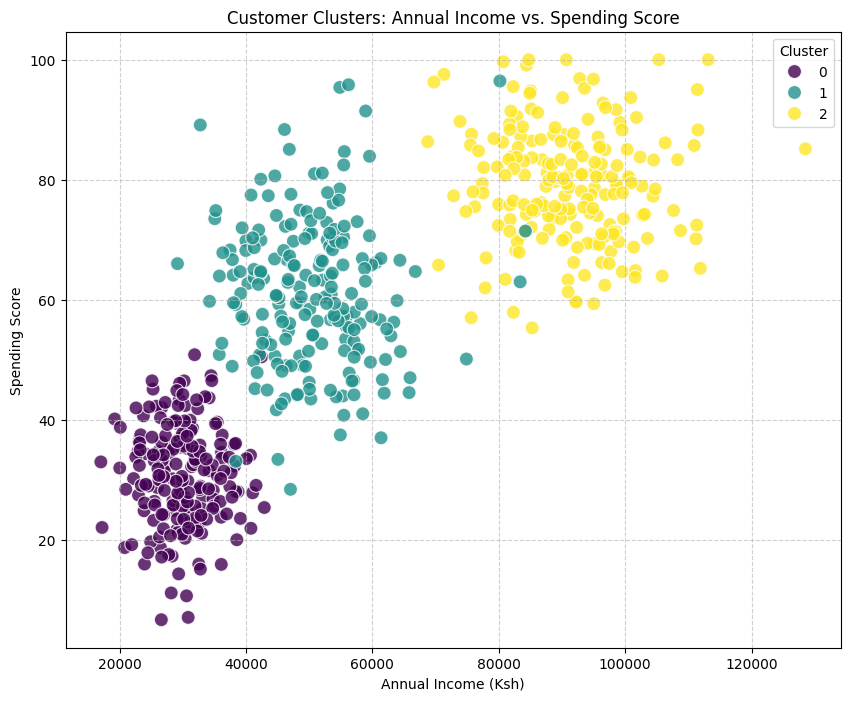

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual_Income_Ksh', y='Spending_Score', hue='Cluster', data=data, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Clusters: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (Ksh)')
plt.ylabel('Spending Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

In [ ]:
# cluster 0 had the lowest online engagement/lowest purchasing frequency/lowest annual income/spending score
#cluster 1 highest online engagement/fair purchase frequency
#cluster 2 highest purchase frequency but low online engagement compared to cluster 1

Recommendation
For cluster 0 to be enageged more (online engagement) to improve purchasing frequency and also spending score For cluster 1: Involve this cluster more (online engagement) .Because they have a higher purchase frequency ,more online engagement might expose products of their intrest to them For cluster 2: Customize the online adverts to fit personal preference of this cohort.